# Learning to Optimize Constrained Convex Optimization Problems with HUANet

This notebook demonstrates a learning-to-optimize method presented in the paper  

[T. Tran, et al., HUANet: Hard-Constrained Unrolled ADMM for Constrained Convex Optimization, 2026](https://arxiv.org/abs/2604.13179v1).

**Hard-Constrained Unrolled ADMM Network** (HUANet) is a learning-to-optimize framework that unrolls the iterations of the Alternating Direction Method of Multipliers (ADMM) into a trainable neural network for solving parametric constrained convex optimization problems of the form

\begin{align}
    \min_x \; &f_\lambda(x),
    \\
    \text{s.t.} \; & A_\lambda x = b_\lambda
    \\
    & C_\lambda x \leq d_\lambda
\end{align}
where $\lambda$ is the parameter vector and $f_\lambda$ is a closed convex function.

HUANet embeds a hard-constrained neural network at each ADMM iteration, where equality constraints are enforced via a differentiable correction stage at the network output, and incorporates first-order optimality conditions as soft constraints during training to promote convergence.
It thereby ensures feasibility and improves optimality of the predicted solution.
Readers are referred to the paper for more details.

We will demonstrate HUANet using an entropy maximization example.
We assume basic familiarity with convex optimization, and refer readers to [[Boyd and Vandenberghe, 2004](https://web.stanford.edu/~boyd/cvxbook/)] for a longer overview.

## Problem formulation
In this example, we will consider the Entropy Maximization optimization problem (Example 5.13 in [[Boyd and Vandenberghe, 2004](https://web.stanford.edu/~boyd/cvxbook/)]):
\begin{align}
\max_{x_i > 0} \quad & -\sum_{i=1}^{n_x} x_i \log(x_i) \\
\text{s.t.} \quad & C x \le d_\lambda, \\
& \mathbf{1}^\top x = 1.
\end{align}
where $x = [x_1, x_2, \ldots, x_{n_x}]^\top \in \mathbb{R}^{n_x}$ is the decision vector representing a probability distribution,
the matrix $C \in \mathbb{R}^{{n_{in}}\times {n_x}}$ is sampled as $(C)_{ij} \sim N(0,1)$,
and the right-hand side parameter $d_\lambda \in \mathbb{R}^{n_{in}}$ is generated by $d_\lambda = Cv + \epsilon$ with $v_i \sim U(0,1)$ and $\epsilon_i \sim N(0, 0.1)$.
Here, we consider $d_\lambda$ as the problem parameters.

## Overview of HUANet

We review the HUANet method as presented in the reference paper.

### Main idea and method

The ADMM iterations for solving the parametric optimization problem are:
\begin{align}
x^{k+1}, s^{k+1} &= 
\operatorname{argmin}_{x, s} \, f_\lambda(x) + \frac{\rho}{2}\|s - w^k + \rho^{-1}v^k\|^2_2,\\
&\hspace{3em} \text{s.t.} \hspace{1.2em} A_\lambda x = b_\lambda,\\
& \hspace{5.5em}
C_\lambda x + s = d_\lambda,\\
w^{k+1} &= \Pi_{\geq 0}(s^{k+1} + \rho^{-1}v^{k}) \\
v^{k+1} &= v^k + \rho(s^{k+1} - w^{k+1})
\end{align}
where $\Pi$ is the projection operator.

The paper's main idea is to build a learned solver that keeps the structure of ADMM instead of replacing the entire solver with a black-box neural network.
HUANet unfolds the ADMM iterations into $N$ sequential neural layers, where each layer corresponds to an ADMM iteration and executes an identical neural mapping $F_{\theta_p}$.
This is illustrated in the next figure.

**Figure:** HUANet model architecture.
<div>
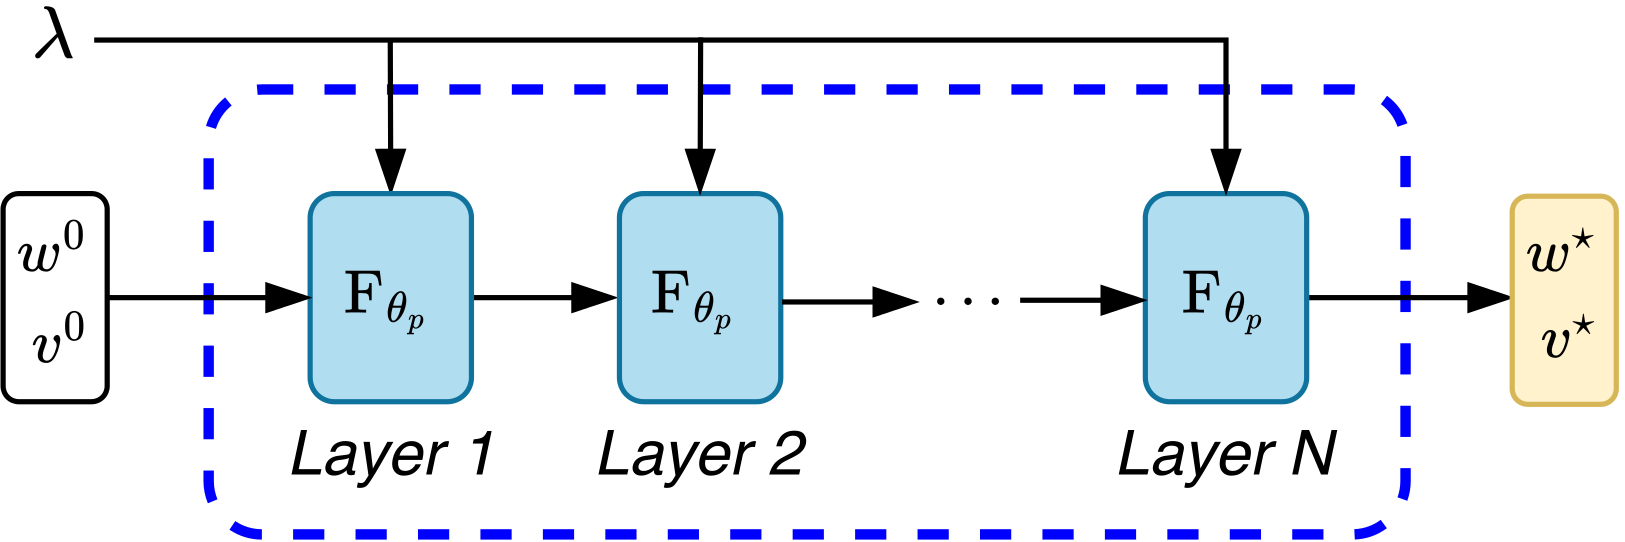
</div>

Each layer $F_{\theta_{p}}$ (see the figure below) maps an iteration index $k$ as follows:

*   The Primal Network $HNN_{\theta_{p}}$ is a hard-constrained neural network designed to learn the optimal solution of the primal update. As illustrated in the figure, it consists of a Multi-Layer Perceptron (MLP) that maps the current problem context into an unconstrained estimate of the primal-slack variable pair
\begin{equation}
(q^{k}, \lambda) \mapsto \overline{y}^{k+1} = \begin{bmatrix} \overline{x}^{k+1} \\ \overline{s}^{k+1} \end{bmatrix}
\end{equation}
where $q^k = w^k - {\rho}^{-1}v^k$.
It is followed by a *feasibility layer*, which adjusts the predicted solution from the primal network to satisfy the constraints.
Practical implementation of the feasibility layer will be discussed later.

*   The output of $HNN_{\theta_{p}}$ then goes through the auxiliary and dual updates of the ADMM iterations.

**Figure:** Architecture of one layer $F_{\theta_{p}}$ in a HUANet model.
<div>
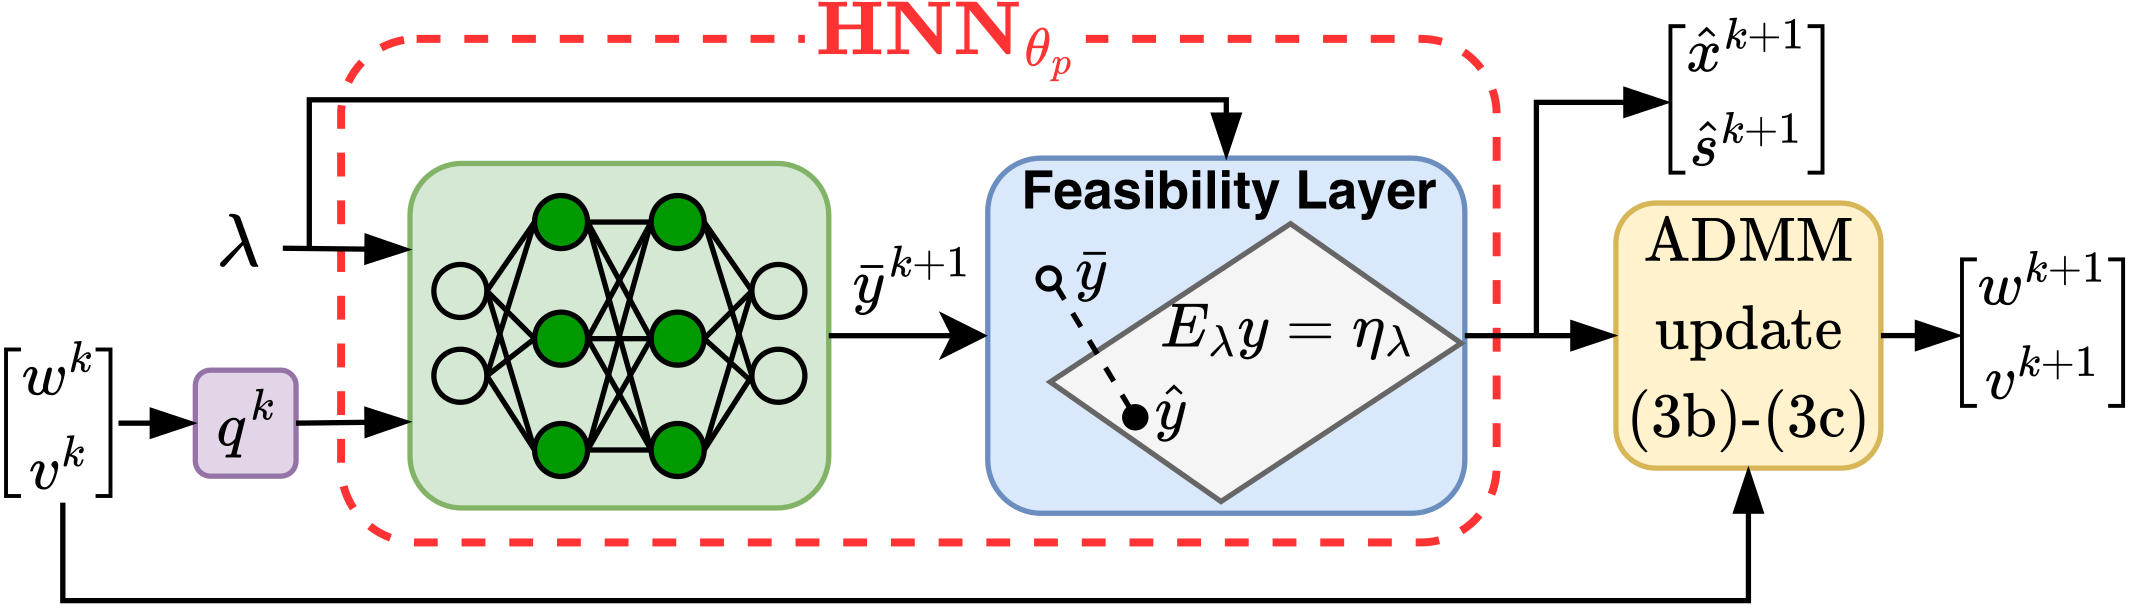
</div>

### HUANet model architecture and training pipeline

While the above architecture guarantees primal feasibility via the correction stage, it alone is insufficient to satisfy the optimality conditions. Optimality sufficient conditions for the primal update require both primal feasibility and stationary conditions, achieved via first-order Karush-Kuhn-Tucker (KKT) optimality criteria, which is enforced in HUANet via a loss term (soft constraint).

To compute these criteria, a secondary network $MLP_{\theta_{d}}$, called a `DualNet`, is implemented to estimate the Lagrange multipliers of the primal updates, trained together with the primal model $HNN_{\theta_{p}}$.
The overall HUANet model architecture and its training pipeline are presented in the following figure and detailed in the reference paper.

**Figure:** HUANet Training Pipeline.
<div>
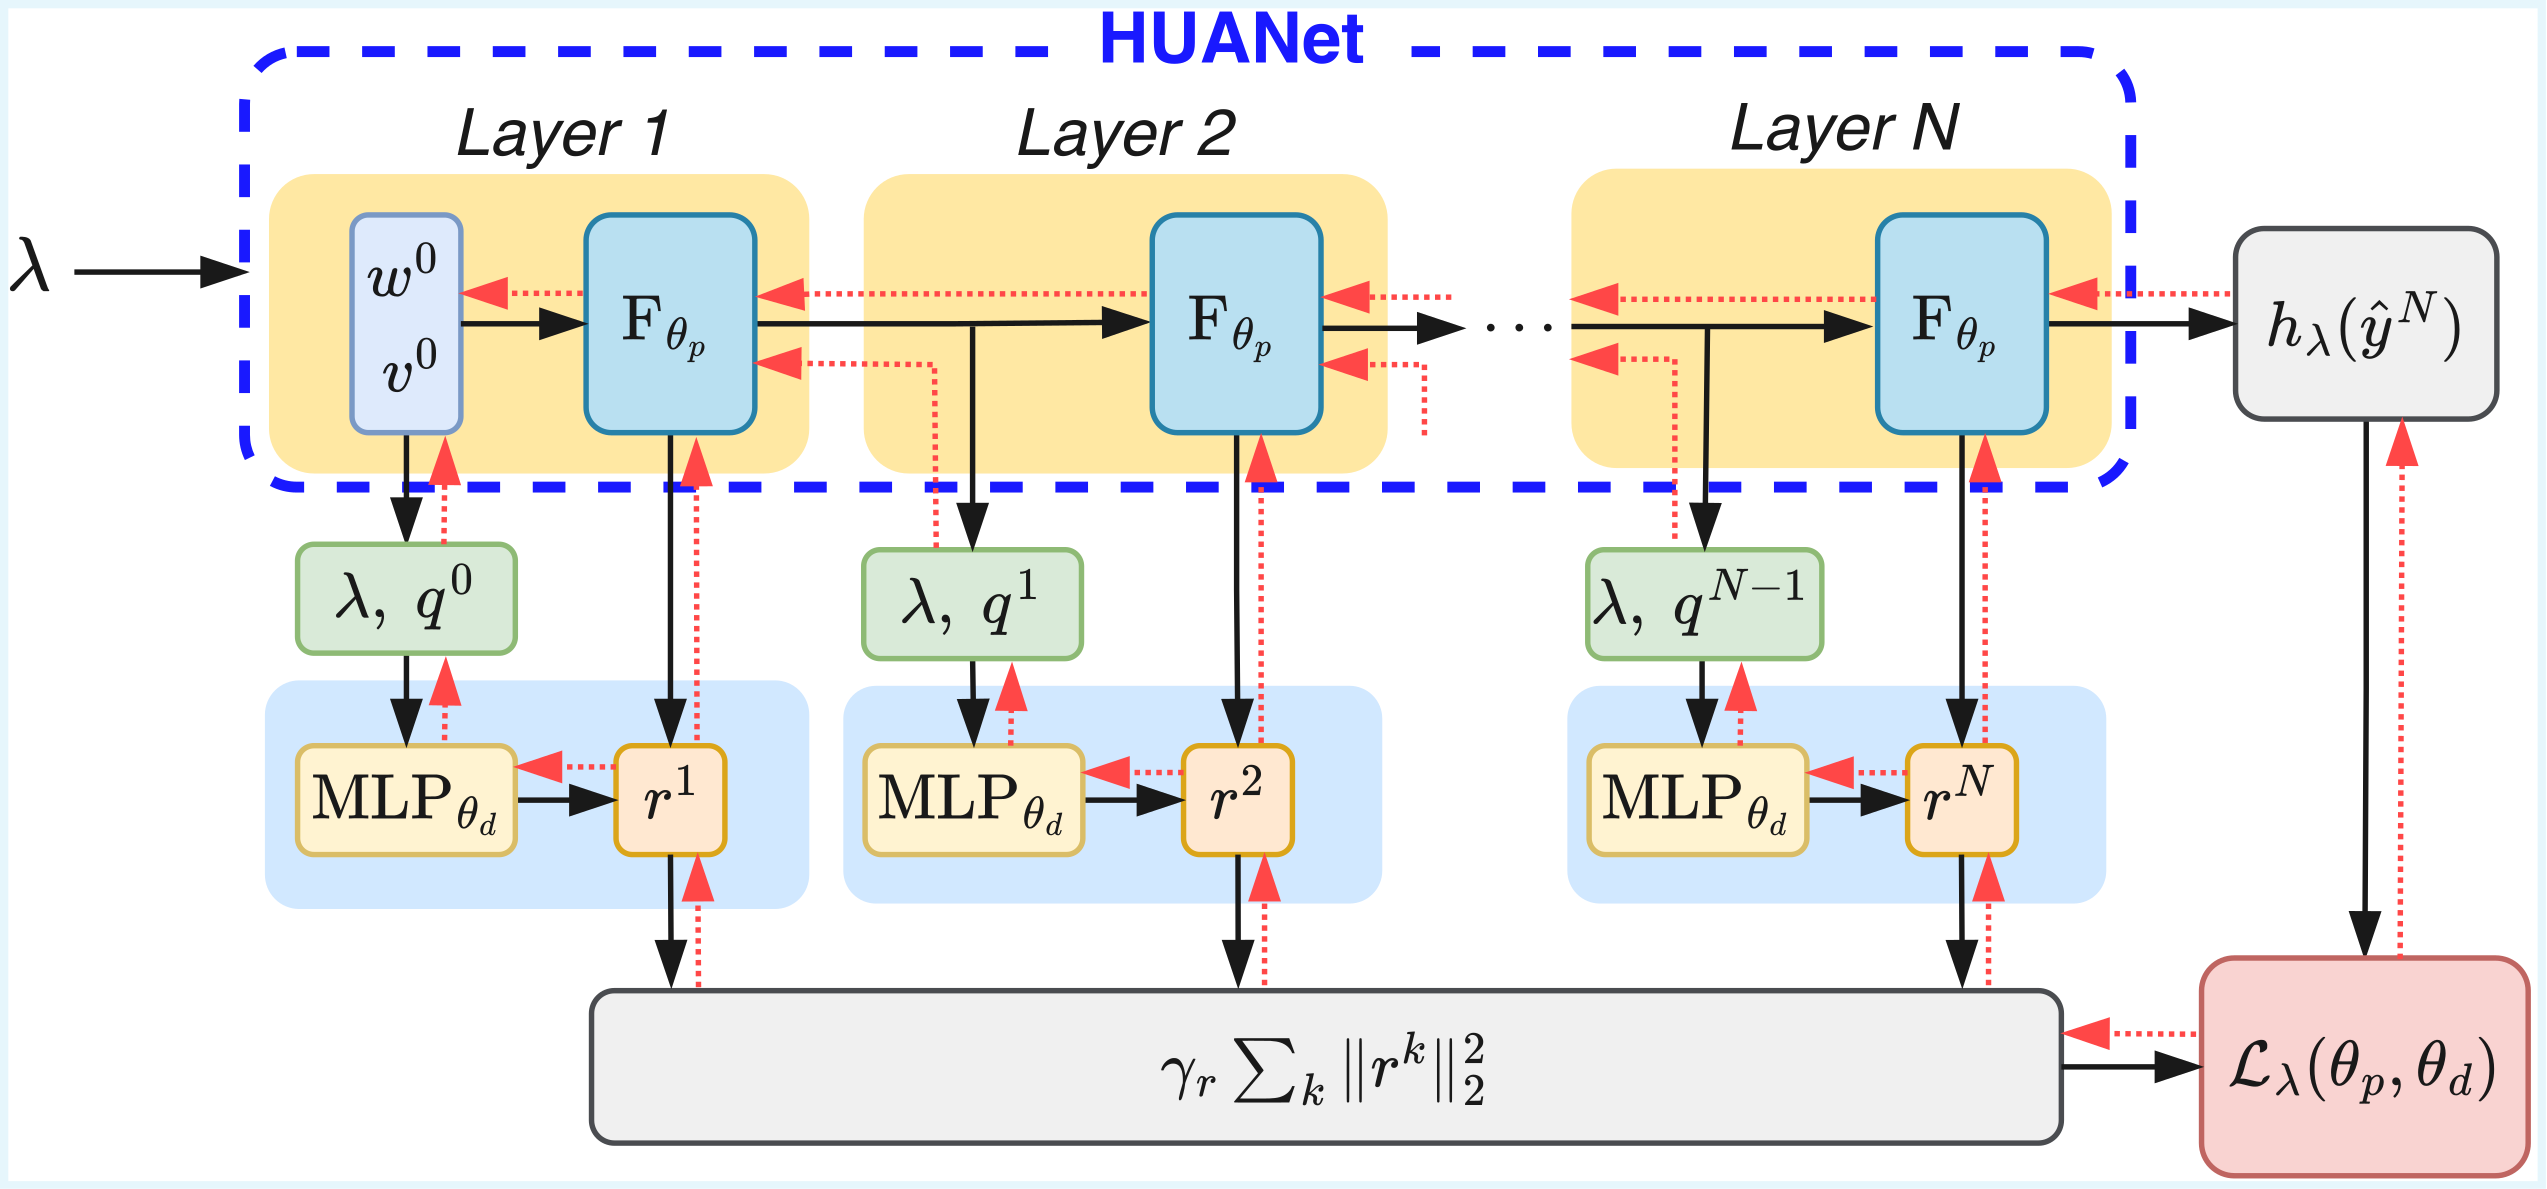
</div>

HUANet is trained in a self-supervised manner.
For a mini-batch of $S$ sampled parameter instances, HUANet coordinates its joint optimization of $(\theta_{p}, \theta_{d})$ by minimizing a composite penalty function:
\begin{equation}
{L}_{\lambda}(\theta_{p}, \theta_{d}) = \frac{1}{S}\sum_{i=1}^{S} \left( h_{\lambda}(\hat{y}_{i}^{N}) + \gamma_{r}\sum_{k=1}^{N}\|r_{i}^{k}\|_{2}^{2} \right)
\end{equation}
where the terminal cost $h_{\lambda}(\hat{y}_{i}^{N}) = f_{\lambda}(\hat{x}_{i}^{N}) + \gamma_{s}\|\max(0, -\hat{s}_{i}^{N})\|_{2}^{2}$ enforces objective optimality and inequality-violation penalties at the last layer/iteration.
The residual cost $\gamma_{r}\sum_{k=1}^{N}\|r_{i}^{k}\|_{2}^{2}$ penalizes departure from the stationary conditions throughout execution to improve overall solver stability/convergence.

### Feasibility layer

As presented above, the feasibility layer of $HNN_{\theta_p}$ adjusts the unconstrained estimate $\bar y = [\bar x^\top, \bar s^\top]^\top$ of the primal update to satisfy the equality constraints $A_\lambda x = b_\lambda$ and $C_\lambda x + s = d_\lambda$.
This is typically done by projecting $\bar y$ onto the affine subspace defined by the equality constraints, represented as a constrained optimization problem
$$
\hat y = \arg\min_y \frac{1}{2}\|y - \bar y\|_2^2
\quad \text{s.t.} \quad
E_\lambda y = \eta_\lambda,
$$
where
$$
E_\lambda =
\begin{bmatrix}
A_\lambda & 0 \\
C_\lambda & I
\end{bmatrix},
\qquad
\eta_\lambda =
\begin{bmatrix}
b_\lambda \\
d_\lambda
\end{bmatrix}.
$$

By using standard least-square, the closed-form correction is obtained as
$$
\hat y = \bar y + E_\lambda^+ (\eta_\lambda - E_\lambda\bar y)
$$
where $E_\lambda^+$ is the Moore-Penrose inverse (aka. pseudoinverse) of $E_\lambda$.

#### Practical implementation of the feasibility layer

While the feasibility layer admits a closed-form equation above, its practical implementation requires careful considerations.
In particular, during training, the quantities $f(x_i^k)$, $\nabla f(x_i^k)$, and $\nabla^2 f(x_i^k)$ must be well-defined for all $x_i^k$, which may not hold if $x_i^k$ lies outside the domain of $f$.
A projection operator can enforce the equality constraints but may not guarantee that these quantities are well-defined at the projected points, which may prevent the training process from progressing.
To address this issue in these cases, for training, the feasibility layer can be implemented as follows:

1. Let $X$ denote the common domain of $f(x)$, $\nabla f(x)$, and $\nabla^2 f(x)$. We project $\bar{x}$ onto $\{x \in X | A_\lambda x = b_\lambda\}$ to get a feasible point $\hat{x}$. If this is not possible, we project $\bar{x}$ onto $A_\lambda x = b_\lambda$ then onto $X$ to obtain a feasible point $\hat{x}$.
2. We then calculate the slack $\hat{s} = d_\lambda - C_\lambda \hat{x}$.

The output of the feasibility is given by $\hat {y} = [ \hat{x}^\top, \hat{s}^\top ]^\top$.
It is necessary that $\hat{s} \geq 0$ to satisfy the inequality constraint; therefore, a loss term penalizing negative $\hat{s}$, such as $\max(0, \hat{s})$, will be included in the training loss function.

The entropy maximization example is such a case.  In this example, the constraints for Step 1 are $x_i > 0$ and $\mathbf{1}^\top x = 1$, which can easily be implemented by a `softmax` activation function.

## Setup

We will use Python and JAX in this example.

- If running locally, install the packages in the files `requirements.txt` (highly recommended using an environment).
- If running on Colab, follow the step below.

### Setup for Colab ONLY

NOTE: Skip this step when running locally.

We will download pre-trained model files from the public repository.

In [ ]:
!wget -q -O entropy_model_10000.npz https://github.com/nxt-lab/HUANet-tutorials-public/blob/master/entropy_model_10000.npz
!wget -q -O entropy_model_2000.npz https://github.com/nxt-lab/HUANet-tutorials-public/blob/master/entropy_model_2000.npz

### Import

Prepare the Python environment by importing packages.

We turn on `jax_enable_x64` flag to switch JAX to using 64-bit numbers for high accuracy.
We set `XLA_FLAGS` before importing JAX and other relevant libraries for creating virtual CPU devices to enable parallel computation; change this value to a number appropriate for the local machine.

In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=20"

import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Tuple

import cvxpy as cp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from jax import random, vmap
from flax import linen as nn
from functools import partial

jax.config.update("jax_enable_x64", True)

## Generating problem instances

We generate a dataset of problem instances, for self-supervised training, by sampling the parametric space as follows:

1. Generate a fixed inequality matrix $C$ by sampling a standard normal distribution.
2. For each random problem instance, generate a candidate vector $x_{\mathrm{feas}}$ ensuring all entries are positive and sum to one, then set $d_\lambda = C x_{\mathrm{feas}} + \epsilon$, where $\epsilon \sim {U}(0, 0.1)$ elementwise.

The generated dataset is saved as a compressed `.npz` file.

In [2]:
# Problem configuration
n_var = 10    # dimension of the decision vector x
n_in  = 5
n_eq  = 5

# Datasetsize
seed      = 2026
n_samples = 2000  # number of problem instances for training; for real training, use 16,000 or more samples

# output_root = "/content/L2O_tutorial/HUANet"

The `generate_data` function generates a single valid problem instance (the vector $d_\lambda$).

In [3]:
def generate_data(key, n_var, C):
    x_raw  = jax.random.uniform(key, (n_var,), minval=0.001, maxval=1.0)
    x_feas = jax.nn.softmax(x_raw)
    lam    = C @ x_feas + jax.random.uniform(key, (C.shape[0],), minval=0.0, maxval=0.1)
    return lam

Now let's create a dataset of problem instances (problem parameters).
The matrix `C` is fixed for the whole experiment, meaning all generated optimization problems share the same left-hand-side inequality matrix.

In [4]:
key   = jax.random.PRNGKey(seed)
key_C, key_lam    = random.split(key)

C     = jax.random.normal(key_C, (n_in, n_var))

keys  =  random.split(key_lam, n_samples)
lam   = vmap(lambda k: generate_data(k, C=C, n_var=n_var))(keys)

After generating the samples, we save the generated dataset.

In [5]:
dataset_file = f"datasets_demo_{n_samples}.npz"
dataset_path = dataset_file # os.path.join(output_root, dataset_file)
np.savez_compressed(dataset_path, lam=np.array(lam), C=np.array(C), N_SAMPLES=n_samples, N_VAR=n_var, N_EQ=n_eq,N_IN=n_in)
print(f"Successfully saved dataset: {dataset_path}")

Successfully saved dataset: datasets_demo_2000.npz


## Implementing HUANet

We implement the HUANet model architecture in JAX by implementing each major component then putting them all together, following the architecture and training pipeline described above.

### Primal network $\mathbf{HNN}_{\theta_p}$

`PrimeNet` is the hard-constrained neural network $\mathbf{HNN}_{\theta_p}$, including the feasibility layer.
The output of `PrimeNet` is $(\hat x, \hat s)$, which is the estimated solution of the primal update.
In this example, the feasibility layer uses `softmax` to implement its first step to compute $\hat x$, then calculate the slack $\hat s$.

In [6]:
class PrimeNet(nn.Module):
    hidden_layers: tuple[int, ...]
    n_var:  int
    n_in: int

    def setup(self) -> None:
        # Initialization
        self.kernel_init = nn.initializers.xavier_uniform()
        self.bias_init   = nn.initializers.zeros_init()

    @nn.compact
    def __call__(self, nn_input: jnp.ndarray, C: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray]:
        x = nn_input
        for features in self.hidden_layers:
            x = nn.Dense(features, kernel_init=self.kernel_init, bias_init=self.bias_init)(x)
            x = nn.gelu(x)

        output = nn.Dense(self.n_var + self.n_in, kernel_init=self.kernel_init, bias_init=self.bias_init)(x)
        x_bar = output[:, :self.n_var]
        x_hat = nn.softmax(x_bar)
        
        # Slack: s = lam_param - C @ x
        lam_param = nn_input[:, self.n_in:]
        s_hat = lam_param - x_hat @ C.T               # (batch, n_in)

        return x_hat, s_hat

### Dual network $\mathbf{MLP}_{\theta_d}$

`DualNet` is the MLP neural network used to estimate the Lagrange multiplier in the primal ADMM subproblem. Specifically, it learns

$$
z^{k+1} \approx \mathbf{MLP}_{\theta_d}(q^k, d_\lambda).
$$
We then calculate the KKT stationarity residual as follows

$$
r^{k+1}
= \nabla f_\lambda(\hat x^{k+1})
+ A_\lambda^\top z^{k+1}
+ \rho C_\lambda^\top(q^k - \hat s^{k+1}).
$$

During training, HUANet penalizes this residual so the learned primal update is not only feasible, but also closer to satisfying first-order optimality conditions.


In [7]:
class DualNet(nn.Module):
    n_eq:         int
    hidden_layers: tuple[int, ...]

    def setup(self) -> None:
        self.kernel_init = nn.initializers.xavier_uniform()
        self.bias_init   = nn.initializers.zeros_init()

    @nn.compact
    def __call__(self, nn_input: jnp.ndarray) -> jnp.ndarray:
        x = nn_input
        for features in self.hidden_layers:
            x = nn.Dense(features, kernel_init=self.kernel_init, bias_init=self.bias_init)(x)
            x = nn.gelu(x)
        return nn.Dense(self.n_eq, kernel_init=self.kernel_init, bias_init=self.bias_init)(x)

### HUANet layer

With the two subnetworks defined, `HUANet` connects `PrimeNet` and `DualNet` into one layer of HUANet for the training pipeline (see the diagram above). It first concatenates the ADMM input $q^k$ with the problem right-hand side $d_\lambda$, then sends this concatenated input to both subnetworks.


In [8]:
class HUANet(nn.Module):
    hidden_layers: tuple[int, ...]
    n_var:  int
    n_in: int
    n_eq: int

    def setup(self) -> None:
        self.prime_net = PrimeNet(hidden_layers=self.hidden_layers, n_var=self.n_var, n_in=self.n_in)
        self.dual_net  = DualNet(hidden_layers=self.hidden_layers, n_eq=self.n_eq)

    def __call__(self, q:jnp.ndarray, lam_param:jnp.ndarray, C: jnp.ndarray, eta:jnp.ndarray = None, return_z: bool = False) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
        nn_input = jnp.concatenate([q, lam_param], axis=-1)
        x_hat, s_hat = self.prime_net(nn_input, C)
        nn_z = self.dual_net(nn_input)

        return x_hat, s_hat, nn_z

### HUANet for unrolled ADMM

Now that we've designed the HUANet layer, we will implement $N$ HUANet layers as an unrolled ADMM trajectory via `unrolled_admm`.

In [9]:
def unrolled_admm(params, model, C: jnp.ndarray, lam_param:jnp.ndarray, batch_size: int, n_admm:int, n_var:int, n_in:int, rho:float, eps:float,gamma:float) -> Tuple[float, Tuple[float, float, float]]:
    nn_params = params["nn"]
    w_k = jnp.zeros((batch_size, n_in))
    v_k = jnp.zeros_like(w_k)
    s_k = jnp.zeros_like(w_k)

    def single_step(carry, _):
        w, v, _ = carry
        q_k = w - v / rho                              # (batch, n_in)

        x_hat, s_hat, z_k = model.apply({"params": nn_params}, q_k, lam_param, C)

        # Objective: f(x) = sum(x * log x)
        f_val = jnp.sum(x_hat * jnp.log(jnp.clip(x_hat, 1e-15)), axis=-1)   # (batch,)

        # KKT stationarity residual
        beta_k = -rho * (s_hat - q_k)
        grad_f = jnp.log(jnp.clip(x_hat, 1e-15)) + 1.0   # (batch, n_var)
        r1 = grad_f + (beta_k @ C) + z_k @ jnp.ones((z_k.shape[-1], n_var)) # (batch, n_var)
        r1_sq  = jnp.sum(r1 ** 2, axis=-1)                # (batch,)

        w_next = jnp.maximum(0.0, s_hat + v / rho)
        v_next = v + rho * (s_hat - w_next)

        return (w_next, v_next, s_hat), (f_val, r1_sq)

    (_, _, s_hat), (f_hist, r1_sq_hist) = jax.lax.scan(single_step, (w_k, v_k, s_k), None, length=n_admm, unroll=True)

    f_terminal  = jnp.mean(f_hist[-1])
    kkt_r1      = jnp.mean(jnp.sum(r1_sq_hist, axis=0) / n_var)
    kkt_last_r1 = jnp.mean(r1_sq_hist[-1]) / n_var
    viol        = jnp.mean(jnp.sum(jnp.maximum(0, -s_hat), axis=-1) / n_in)

    total_loss = f_terminal + eps * kkt_r1 + gamma * viol

    return total_loss, (f_terminal, kkt_last_r1, viol)


### Training step

After defining the unrolled trajectory, `train_step` performs one gradient update of HUANet. It evaluates the unrolled loss ${L}(\theta)$,
then uses automatic differentiation to compute $\nabla_\theta {L}$ and updates the parameters with AdamW.
The JIT annotation compiles this update so repeated training epochs run faster.

In [10]:
@partial(jax.jit, static_argnames=["model", "optimizer", "batch_size", "n_admm", "n_var", "n_in"])
def train_step(params, opt_state, model, lam_param:jnp.ndarray, batch_size:int, n_admm:int, n_var:int, n_in:int, rho:float, eps:float, gamma:float, optimizer) -> Tuple[jnp.ndarray, jnp.ndarray, float, float, float, float]:
    def loss_fn(all_params):
        return unrolled_admm(
            all_params, model, C,
            lam_param, batch_size, n_admm, n_var, n_in, rho, eps, gamma,
        )

    (loss, (f_terminal, kkt_last, viol)), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    updates, opt_state_new = optimizer.update(grads, opt_state, params)
    params_new = optax.apply_updates(params, updates)

    return params_new, opt_state_new, loss, f_terminal, kkt_last, viol

## Validation

For validation, `make_validator` builds a fixed-parameter HUANet solver. It runs the same ADMM recurrence as training,
$$
q^k \rightarrow \hat x^{k+1} \rightarrow \hat s^{k+1} \rightarrow (w^{k+1}, v^{k+1}),
$$
but without gradients or parameter updates. The output is the final predicted solution $\hat x^N$.

In [11]:
def make_validator(nn_params, model, C: jnp.ndarray, n_admm: int, rho: float):
    @jax.jit
    def solve(lam_batch: jnp.ndarray) -> jnp.ndarray:
        n_samples, n_in = lam_batch.shape
        w_init = jnp.zeros((n_samples, n_in))
        v_init = jnp.zeros_like(w_init)
        x_init = jnp.zeros((n_samples, model.n_var))

        def body_fn(carry, _):
            w_k, v_k, _ = carry
            q_k    = w_k - v_k / rho
            x_next, s_next, _ = model.apply({"params": nn_params}, q_k, lam_batch, C)
            w_next = jnp.maximum(0.0, s_next + v_k / rho)
            v_next = v_k + rho * (s_next - w_next)
            return (w_next, v_next, x_next), None

        (_, _, x_final), _ = jax.lax.scan(body_fn, (w_init, v_init, x_init), None, length=n_admm)
        return x_final

    return solve

The following function validates a trained HUANet model.

In [12]:
def validate(params, model, C: jnp.ndarray, lam_val, batch_size, n_admm, rho):
    nn_params = params["nn"]
    solve = make_validator(nn_params, model, C, n_admm, rho)
    # warm up
    _ = solve(jnp.zeros((1, lam_val.shape[1]))).block_until_ready()

    all_x = []
    for start in range(0, len(lam_val), batch_size):
        lam_batch = jnp.array(lam_val[start : min(start + batch_size, len(lam_val))])
        x_hat = solve(lam_batch)
        x_hat.block_until_ready()
        all_x.append(np.array(x_hat))
    x_pred = np.concatenate(all_x, axis=0)

    lam_np = np.array(lam_val[: len(x_pred)])
    C_np   = np.array(C)

    x_safe = np.clip(x_pred, 1e-15, None)
    obj    = float(np.mean(np.sum(x_safe * np.log(x_safe), axis=1)))

    ineq_resid    = np.maximum(0, (x_pred @ C_np.T) - lam_np)
    ineq_viol_max = float(np.max(np.max(ineq_resid, axis=1)))

    eq_viol = np.abs(np.sum(x_pred, axis=1) - 1.0)
    eq_viol_max = float(np.max(eq_viol))

    return {
        "obj":         obj,
        "ineq_viol_max": ineq_viol_max,
        "eq_viol_max":   eq_viol_max,
    }

Finally, `print_val_summary` formats the validation dictionary into a compact report: objective value, maximum equality violation, and maximum inequality violation.


In [13]:
def print_val_summary(epoch, metrics):
    print(f"\nVALIDATION at epoch {epoch}")
    print("=" * 60)
    print(f"  Objective:           {metrics['obj']:.6e}")
    print(f"  Eq  violation max: {metrics['eq_viol_max']:.6e}")
    print(f"  Ineq violation max: {metrics['ineq_viol_max']:.6e}")
    print("=" * 60)

## Training HUANet

With the dataset prepared and the HUANet model and training pipeline implemented, we now train a HUANet model for the entropy maximization problem.

### Training hyperparameters

We first set the training hyperparameters.
For demonstration purposes, we will set the epoch number `n_epochs` to a small value `100`.
In real training, it should be set to a large number, such as 5000.

In [14]:
train_percent = 0.8             # Fraction of generated dataset used for training
val_percent = 0.1               # Fraction used for validation
test_percent = 0.1              # Fraction used for testing
batch_size = 32                 # Mini-batch size
n_epochs = 500                  # Number of training epochs/iterations; should be 20,000 or more for real training
n_admm = 20                     # Number of unrolled ADMM steps
rho = 2.0                       # ADMM penalty parameter
hidden_layers = (32, 32)        # HUANet hidden layer sizes
eps = 1.0                       # Weight of KKT residual term
gamma = 1.0e3                   # Weight of primal feasibility violation

### Data preparation

Load the generated entropy dataset and define where the trained HUANet parameters will be saved.

In [15]:
dataset_path = Path(f"datasets_demo_{n_samples}.npz")
model_path   = Path(f"models_demo_{n_samples}.npz")
data         = np.load(dataset_path)

Next, split the generated $d_\lambda$ samples into training, validation, and test pools. Training updates the model, validation monitors generalization during training, and test data are reserved for final benchmarking.

In [16]:
lam_all = data["lam"]          # (n_total, n_eq)
n_train = int(n_samples * train_percent)
n_val   = int(n_samples * val_percent)
n_test = n_samples - n_train - n_val

lam_train_pool = lam_all[:n_train]
lam_val_pool   = lam_all[n_train : n_train + n_val]
lam_test_pool  = lam_all[n_train + n_val : n_train + n_val + n_test]

Create the models, and initialize AdamW and the learning-rate schedule used to optimize the HUANet parameters.

In [17]:
hidden_layers = tuple(hidden_layers)
model = HUANet(hidden_layers=hidden_layers, n_var=n_var, n_in=n_in, n_eq=n_eq)
key   = jax.random.PRNGKey(seed)

nn_params = model.init(key, jnp.zeros((1, n_in)), jnp.zeros((1, n_in)), C)["params"]

params = {"nn": nn_params}

lr_sched = optax.exponential_decay(
    init_value=1e-3,
    decay_rate=0.9,
    transition_steps=1000,
)
optimizer = optax.adamw(learning_rate=lr_sched, weight_decay=1e-4)
opt_state = optimizer.init(params)

### Training loop

Now we run the training loop. Each epoch samples a mini-batch of $d_\lambda$, evaluates the unrolled loss, updates HUANet parameters, and keeps the best parameter set observed so far.
Periodic validation checks whether the learned solver remains feasible and stable on held-out problem instances.

In [18]:
print("=" * 80)
print("Training Entropy — HUANet (feasibility mode)")
print("=" * 80)
rng        = np.random.default_rng(seed)
best_loss  = float("inf")
best_params = params

for epoch in range(n_epochs):
    batch_idx  = rng.integers(0, n_train, size=batch_size)
    lam_param  = jnp.array(lam_train_pool[batch_idx])

    params, opt_state, loss, f_terminal, kkt_last, viol = train_step(
        params, opt_state, model,
        lam_param, batch_size, n_admm, n_var, n_in, rho, eps, gamma, optimizer,
    )

    if float(loss)  < best_loss:
        best_loss   = float(loss)
        best_params = params

    if epoch % 50 == 0:
        current_lr = float(lr_sched(epoch))
        print(
            f"Epoch {epoch:5d} | loss: {float(loss):.6f} | "
            f"f: {float(f_terminal):.6f} | "
            f"kkt: {float(kkt_last):.6f} | "
            f"viol: {float(viol):.6f} | "
            f"lr: {current_lr:.2e}"
        )

    if epoch % 100 == 0:
        val_metrics = validate(best_params, model, C, lam_val_pool, batch_size, n_admm, rho)
        print_val_summary(epoch, val_metrics)

val_metrics = validate(best_params, model, C, lam_val_pool, batch_size, n_admm, rho)
print_val_summary(n_epochs, val_metrics)

Training Entropy — HUANet (feasibility mode)
Epoch     0 | loss: 285.363877 | f: -2.289943 | kkt: 36.972202 | viol: 0.026234 | lr: 1.00e-03

VALIDATION at epoch 0
  Objective:           -2.285837e+00
  Eq  violation max: 3.330669e-16
  Ineq violation max: 6.023156e-01
Epoch    50 | loss: 17.217608 | f: -2.290956 | kkt: 1.640413 | viol: 0.004431 | lr: 9.95e-04
Epoch   100 | loss: 3.269617 | f: -2.282414 | kkt: 0.227892 | viol: 0.000983 | lr: 9.90e-04

VALIDATION at epoch 100
  Objective:           -2.285433e+00
  Eq  violation max: 3.330669e-16
  Ineq violation max: 9.788320e-02
Epoch   150 | loss: 2.948692 | f: -2.278126 | kkt: 0.166947 | viol: 0.000664 | lr: 9.84e-04
Epoch   200 | loss: 2.170392 | f: -2.274664 | kkt: 0.100665 | viol: 0.000342 | lr: 9.79e-04

VALIDATION at epoch 200
  Objective:           -2.285433e+00
  Eq  violation max: 3.330669e-16
  Ineq violation max: 9.788320e-02
Epoch   250 | loss: 1.368789 | f: -2.272822 | kkt: 0.084150 | viol: 0.000327 | lr: 9.74e-04
Epoch   

The training line reports:

- **loss:** the loss function $L$.
- **f:** the final entropy objective.
- **kkt:** the KKT residual term. Smaller values indicate that the learned update is closer to satisfying first-order optimality conditions.
- **viol:** the inequality-violation penalty.
- **lr:** the learning rate at that epoch.

The training process shows decreasing loss, small validation equality violation, and small validation inequality violation.


After training, save the best HUANet parameters and metadata.

In [19]:
np.savez_compressed(
    model_path,
    params=jax.tree_util.tree_map(np.array, best_params),
    best_loss=float(best_loss),
    n_epochs=n_epochs,
    n_train=n_train,
    n_val=n_val,
    n_test=n_test,
    scenario_n_var=n_var,
    hidden_layers=np.array(hidden_layers),
)
print(f"Saved trained model to {model_path}")

Saved trained model to models_demo_2000.npz


## Evaluation results

After training the HUANet model, we evaluate it on test problem instances.
In the first benchmark, using [Clarabel](https://clarabel.org/stable/) as ground truth, we report the **optimality gap** and **feasibility** of the solution obtained by HUANet.
We also compare the **solve time** between HUANet, Clarabel, and [SCS](https://www.cvxgrp.org/scs/) to demonstrate the computational performance of the learned solver relative to traditional solvers.
After that, we compare runtime between learned unrolled ADMM and classical ADMM.

### Benchmark setup

The function `make_l2o_solver` builds the trained HUANet inference solver.
The implementation uses `pmap` so batches can be shared across available JAX devices.

In [20]:
def make_l2o_solver(nn_params, model: HUANet, C: jnp.ndarray, n_var: int, n_in: int, n_admm: int, rho: float):
    @jax.pmap
    def solve(lam_batch: jnp.ndarray) -> jnp.ndarray:
        n_samples = lam_batch.shape[0]

        w_init = jnp.zeros((n_samples, n_in))
        v_init = jnp.zeros_like(w_init)
        x_init = jnp.zeros((n_samples, n_var))

        def body_fn(_, carry):
            w_k, v_k, _ = carry
            q_k    = w_k - v_k / rho
            x_next, s_next, _ = model.apply({"params": nn_params}, q_k, lam_batch, C)
            w_next = jnp.maximum(0.0, s_next + v_k / rho)
            v_next = v_k + rho * (s_next - w_next)
            return w_next, v_next, x_next

        _, _, x_final = jax.lax.fori_loop(0, n_admm, body_fn, (w_init, v_init, x_init), unroll=True)
        return x_final

    return solve

For comparison, `baseline_solver` solves the original entropy problem with [CVXPY](https://www.cvxpy.org/).

In [21]:
def baseline_solver(lam_samples: np.ndarray, C: np.ndarray, n_var: int, solver_name: str) -> Tuple[np.ndarray, np.ndarray]:
    x_batch, solve_times = [], []
    for lam_sample in lam_samples:
        x = cp.Variable(n_var)
        problem = cp.Problem(cp.Minimize(cp.sum(cp.entr(x) * -1)),
            [C @ x <= lam_sample, cp.sum(x) == 1],
        )
        problem.solve(solver=solver_name, warm_start=True, verbose=False)
        x_batch.append(np.asarray(x.value, dtype=float))
        solve_times.append(problem.solver_stats.solve_time)

    return np.array(x_batch), np.array(solve_times, dtype=float)

Using the solver outputs, `benchmark_metrics` compares HUANet predictions with reference solver solutions. It reports objective gap, equality violation, inequality violation, and solve time.

In [22]:
def benchmark_metrics(x_pred:np.ndarray, x_true:np.ndarray, C:np.ndarray, lam_test:np.ndarray, run_time:np.ndarray) -> dict:
    # Objective: f(x) = sum(x * log x)
    x_safe_pred = np.clip(x_pred, 1e-15, None)
    x_safe_true = np.clip(x_true, 1e-15, None)
    obj_pred = np.sum(x_safe_pred * np.log(x_safe_pred), axis=1)
    obj_true = np.sum(x_safe_true * np.log(x_safe_true), axis=1)

    gap_percent = np.abs((obj_pred - obj_true) / np.maximum(np.abs(obj_true), 1e-10)) * 100

    # Inequality: Cx <= lam
    ineq_resid = np.maximum(0, (x_pred @ C.T) - lam_test)   # (n_samples, n_ineq)
    ineq_viol  = np.max(ineq_resid, axis=1)

    # Equality: 1^T x = 1
    eq_viol = np.abs(np.sum(x_pred, axis=1) - 1.0)

    return {
        "mean_obj_gap": np.mean(gap_percent),
        "max_obj_gap": np.max(gap_percent),
        "mean_ineq_viol": np.mean(ineq_viol),
        "max_ineq_viol": np.max(ineq_viol),
        "mean_eq_viol": np.mean(eq_viol),
        "max_eq_viol": np.max(eq_viol),
        "mean_solve_time": np.mean(run_time),
        "max_solve_time": np.max(run_time),
    }

### Benchmark execution

Next, we run the main benchmark.

Instead of using the model trained above, we will load a pre-trained model. There are several pre-trained models that can be selected: a small model trained on 2000 problem instances, and a larger (slower) but more accurate model trained on 10000 problem instances.

Once the trained HUANet model is loaded, it is evaluated on the test set and compared with Clarabel and SCS on the same $d_\lambda$ instances.
The warm-up call removes JAX compilation time from the measured inference times.
For HUANet, the code uses **per-batch timing**. The test samples are padded and sharded across the available JAX devices. For each sharded batch, the code records wall-clock time around one `l2o_solve` call and uses `block_until_ready()` so asynchronous JAX execution finishes before the timer stops.

The elapsed batch time is then assigned to the samples in that batch, giving a per-instance solve-time array `l2o_times`.

In [23]:
# Pre-trained model file; use entropy_model_2000.npz for the smaller/faster but less accurate model
model_path = "entropy_model_10000.npz"

# -- Load trained model --
saved            = np.load(model_path, allow_pickle=True)
saved_params_obj = saved["params"].item()
hidden_layers    = tuple(saved["hidden_layers"])

# -- Build model --
model     = HUANet(hidden_layers=hidden_layers, n_var=n_var, n_in=n_in, n_eq=n_eq)
nn_params = saved_params_obj["nn"]

# ---- HUANet ----
l2o_solve = make_l2o_solver(nn_params=nn_params, model=model, C=C, n_var=n_var, n_in=n_in, n_admm=n_admm, rho=rho)
n_devices = jax.local_device_count()
print(f"Using {n_devices} CPU devices via pmap")
pad = (n_devices - len(lam_test_pool) % n_devices) % n_devices
if pad > 0:
    lam_padded = jnp.concatenate(
        [lam_test_pool, jnp.zeros((pad, n_in), dtype=lam_test_pool.dtype)], axis=0
    )
else:
    lam_padded = lam_test_pool
per_device = len(lam_padded) // n_devices

# Warm up
lam_warm = jnp.zeros((n_devices, 1, n_in), dtype=lam_test_pool.dtype)
_ = l2o_solve(lam_warm).block_until_ready()

# Per-batch timing
l2o_times  = []
x_pred_list = []
for i in range(per_device):
    lam_slice         = lam_padded[i * n_devices:(i + 1) * n_devices]   # (n_devices, n_in)
    lam_slice_sharded = lam_slice[:, None, :]                            # (n_devices, 1, n_in)
    start   = time.perf_counter()
    x_slice = l2o_solve(lam_slice_sharded)
    x_slice.block_until_ready()
    elapsed = time.perf_counter() - start
    x_pred_list.append(np.array(x_slice[:, 0, :]))                      # (n_devices, n_var)
    l2o_times.extend([elapsed / n_devices] * n_devices)

x_pred_array = np.vstack(x_pred_list)[:len(lam_test_pool)]
l2o_times    = np.array(l2o_times[:len(lam_test_pool)], dtype=float)
sequential_time = float(np.mean(l2o_times))
C_np = np.array(C)

Using 20 CPU devices via pmap


Run benchmarks of traditional solvers.

In [24]:
print(f"Running L2O...")
# ---- Clarabel ----
print("Running Clarabel...")
x_clarabel, solve_times_clarabel = baseline_solver(lam_test_pool, C_np, n_var, cp.CLARABEL)
# ---- SCS ----
print("Running SCS...")
x_scs, solve_times_scs = baseline_solver(lam_test_pool, C_np, n_var, "SCS")

Running L2O...
Running Clarabel...
Running SCS...


### Benchmark results vs traditional solvers

After running all solvers, print a compact metric table for the learned solver. Each metric is shown in `(mean)max` format, so the table reports both typical behavior and worst-case behavior over the test set.


In [25]:
l2o_metrics = benchmark_metrics(x_pred_array, x_clarabel, C_np, np.array(lam_test_pool), l2o_times)

def mean_max(metrics, mean_key, max_key):
    return f"{metrics[mean_key]:.3e} ({metrics[max_key]:.3e})"

headers = [
    "Metrics",
    "n_var",
    "(n_eq, n_in)",
    "Optimality gap (%)",
    "Eq.violation",
    "Ineq.violation",
    "Solve time (s)",
]
row = [
    "HUANet",
    str(n_var),
    f"({n_eq}, {n_in})",
    mean_max(l2o_metrics, "mean_obj_gap", "max_obj_gap"),
    mean_max(l2o_metrics, "mean_eq_viol", "max_eq_viol"),
    mean_max(l2o_metrics, "mean_ineq_viol", "max_ineq_viol"),
    mean_max(l2o_metrics, "mean_solve_time", "max_solve_time"),
]

widths = [max(len(header), len(value)) for header, value in zip(headers, row)]
header_line = "| " + " | ".join(header.ljust(width) for header, width in zip(headers, widths)) + " |"
divider = "| " + " | ".join("-" * width for width in widths) + " |"
row_line = "| " + " | ".join(value.ljust(width) for value, width in zip(row, widths)) + " |"

print(f"Number of test samples: {n_test}\n")

print(header_line)
print(divider)
print(row_line)

Number of test samples: 200

| Metrics | n_var | (n_eq, n_in) | Optimality gap (%)    | Eq.violation          | Ineq.violation        | Solve time (s)        |
| ------- | ----- | ------------ | --------------------- | --------------------- | --------------------- | --------------------- |
| HUANet  | 10    | (5, 5)       | 6.101e-04 (7.057e-03) | 6.883e-17 (2.220e-16) | 1.716e-05 (5.675e-04) | 2.460e-05 (3.017e-05) |


After the table, plot the solve-time distributions for HUANet, Clarabel, and SCS.

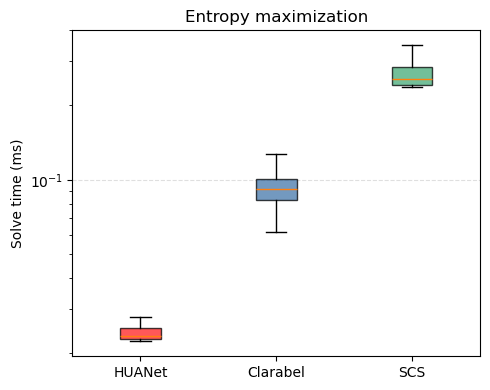



Mean solving times (ms): 0.0246, 0.0956, 0.268


In [26]:
times_ms = [
    np.asarray(l2o_times) * 1e3,
    np.asarray(solve_times_clarabel) * 1e3,
    np.asarray(solve_times_scs) * 1e3,
]
tick_labels = ["HUANet", "Clarabel", "SCS"]
colors = ["#FF2020", "#4477AA", "#44AA77"]

fig, ax = plt.subplots(figsize=(5.0, 4.0))
box = ax.boxplot(times_ms, tick_labels=tick_labels, showfliers=False, patch_artist=True)
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel("Solve time (ms)")
ax.set_title("Entropy maximization")
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\n\nMean solving times (ms): " + ", ".join([f"{np.mean(ts):.3g}" for ts in times_ms]))

### Benchmark results vs vanilla ADMM

Here, we implement vanilla ADMM for the entropy problem, then compare its solving time with HUANet.

In [27]:
def primal_solver(lam_samples: np.ndarray, C: np.ndarray, qk: np.ndarray, rho: float, solver_name=cp.CLARABEL) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    n_var = C.shape[1]
    n_eq  = C.shape[0]
    x_batch, s_batch, solve_times = [], [], []
    for i, lam_sample in enumerate(lam_samples):
        x_var = cp.Variable(n_var)
        s_var = cp.Variable(n_eq)
        problem = cp.Problem(cp.Minimize(cp.sum(cp.entr(x_var) * -1)+ 0.5 * rho * cp.sum_squares(s_var - qk[i])),
            [C @ x_var + s_var == lam_sample, cp.sum(x_var) == 1, x_var >= 0],
        )
        problem.solve(solver=solver_name, warm_start=True, verbose=False)
        x_batch.append(x_var.value)
        s_batch.append(s_var.value)
        solve_times.append(problem.solver_stats.solve_time)
    return np.array(x_batch), np.array(s_batch), np.array(solve_times, dtype=float)


def admm(C: np.ndarray, lam_batch: np.ndarray, max_iter: int, tol: float, rho: float) -> Tuple[np.ndarray, np.ndarray]:
    n_samples = lam_batch.shape[0]
    n_var = C.shape[1]
    n_eq  = C.shape[0]

    x_batch          = np.zeros((n_samples, n_var))
    per_sample_times = np.zeros(n_samples)
    per_sample_iters = np.zeros(n_samples, dtype=int)

    for i in range(n_samples):
        lam_i = lam_batch[i : i + 1]   # (1, n_eq)
        w_k   = np.zeros((1, n_eq))
        v_k   = np.zeros_like(w_k)
        x_k   = np.zeros((1, n_var))

        primal_res  = np.inf
        dual_res    = np.inf
        iter_count  = 0
        primal_time = 0.0
        overhead_time = 0.0

        for iter_count in range(1, max_iter + 1):
            t0 = time.perf_counter()
            q_k = w_k - v_k / rho
            overhead_time += time.perf_counter() - t0

            x_next, s_next, iter_times = primal_solver(lam_i, C, q_k, rho)
            primal_time += iter_times[0]

            t0 = time.perf_counter()
            w_next = np.maximum(0.0, s_next + v_k / rho)
            v_next = v_k + rho * (s_next - w_next)

            # Primal residual: ||s - w||_inf
            primal_res = np.max(np.abs(s_next - w_next))
            # Dual residual: rho * ||w_next - w_k||_inf
            dual_res = rho * np.max(np.abs(w_next - w_k))

            w_k, v_k, x_k = w_next, v_next, x_next
            overhead_time += time.perf_counter() - t0

            if primal_res <= tol and dual_res <= tol:
                break

        per_sample_times[i] = overhead_time + primal_time
        x_batch[i] = x_k[0]
        per_sample_iters[i] = iter_count

    return x_batch, per_sample_times

Let's run the vanilla ADMM baseline on the test set.

In [28]:
max_iter = 1000  # number of iterations
tol = 1e-4       # termination threshold

print(f"\nRunning ADMM on {len(lam_test_pool)} samples...")
x_admm, times_admm = admm(C_np, np.array(lam_test_pool), max_iter, tol, rho)


Running ADMM on 200 samples...


Finally, plot the mean solve time of HUANet and direct ADMM.

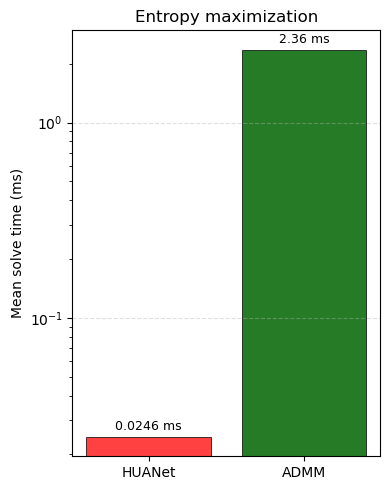

In [29]:
labels = ["HUANet", "ADMM"]
mean_times_ms = [np.mean(l2o_times) * 1e3, np.mean(times_admm) * 1e3]
colors = ["#FF2020", "#006400"]

fig, ax = plt.subplots(figsize=(4.0, 5.0))
bars = ax.bar(labels, mean_times_ms, color=colors, edgecolor="black", linewidth=0.6, alpha=0.85)

for bar, value in zip(bars, mean_times_ms):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value * 1.05,
        f"{value:.3g} ms",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_ylabel("Mean solve time (ms)")
ax.set_title(f"Entropy maximization")
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()